## Reto de la semana 2
Omar Diaz.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive, files

Mounted at /content/drive


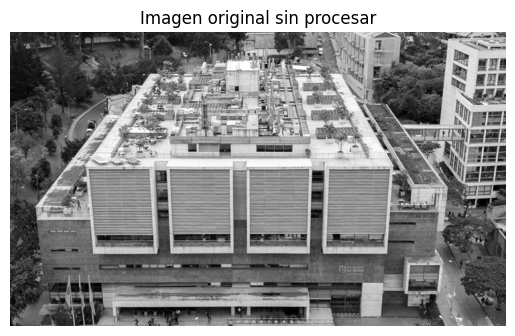

In [ ]:
# Montaje del drive
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/datos')

# Se carga la imagen EdificioMarioLaserna.png
imagen = cv2.imread('EdificioMarioLaserna.png', cv2.IMREAD_GRAYSCALE)
original_size = imagen.size

# Se muestra la imagen original antes de cualquier compresión
plt.imshow(imagen, cmap='gray')
plt.title('Imagen original sin procesar')
plt.axis('off')
plt.show()

In [ ]:
# Realizar el proceso de descomposición SVD con la imagen
U, S, Vt = np.linalg.svd(imagen)

# Proceso de armado de la matriz Sigma (diagonal de valores singulares)
Sigma = np.diag(S)

In [ ]:
# Función para reconstruir la imagen con p valores
def reconstruir_imagen(p):
    imagen_reconstruida = np.dot(U[:, :p], np.dot(Sigma[:p, :p], Vt[:p, :]))
    return imagen_reconstruida

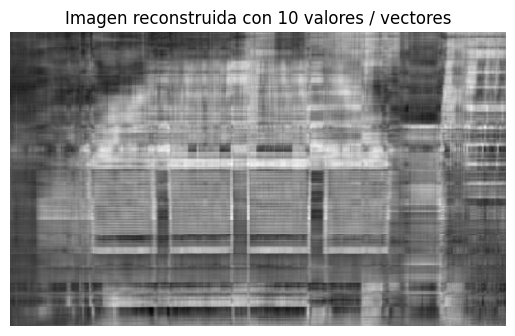

Tamaño de la imagen original: 324860 píxeles
Tamaño de la imagen comprimida: 11890 píxeles
Porcentaje de compresión: 96.340%


In [ ]:
# Reconstruir la imagen usando p = 10 valores / vectores
p = 10
imagen_reconstruida = reconstruir_imagen(p)

# Calculo del tamaño de la imagen comprimida y ratio de compresión
compressed_size = (U[:, :p].size + Sigma[:p, :p].size + Vt[:p, :].size)
def com_ratio(original_size, compressed_size):
    return (1- (compressed_size / original_size))*100

ratio = com_ratio(original_size, compressed_size)

# Mostrar la imagen reconstruida
plt.imshow(imagen_reconstruida, cmap='gray')
plt.title(f'Imagen reconstruida con {p} valores / vectores')
plt.axis('off')
plt.show()
plt

print(f'Tamaño de la imagen original: {original_size} píxeles')
print(f'Tamaño de la imagen comprimida: {compressed_size} píxeles')
print(f'Porcentaje de compresión: {ratio:.3f}%')

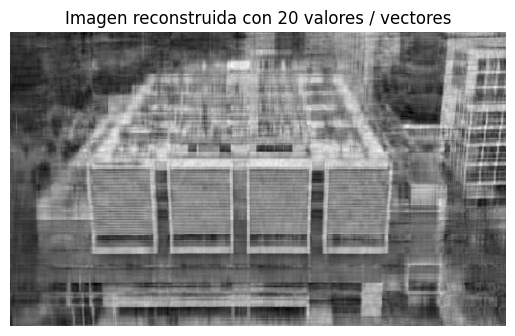

Tamaño de la imagen comprimida con parámetro p = 20: 23980 píxeles
Porcentaje de compresión: 92.618%


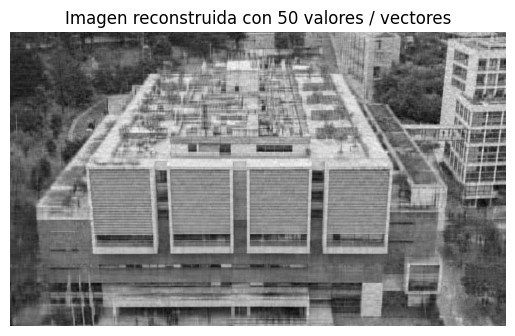

Tamaño de la imagen comprimida con parámetro p = 50: 61450 píxeles
Porcentaje de compresión: 81.084%


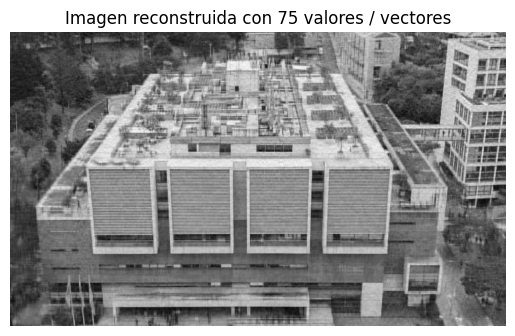

Tamaño de la imagen comprimida con parámetro p = 75: 94050 píxeles
Porcentaje de compresión: 71.049%


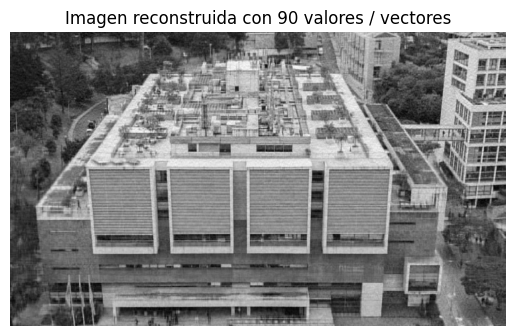

Tamaño de la imagen comprimida con parámetro p = 90: 114210 píxeles
Porcentaje de compresión: 64.843%


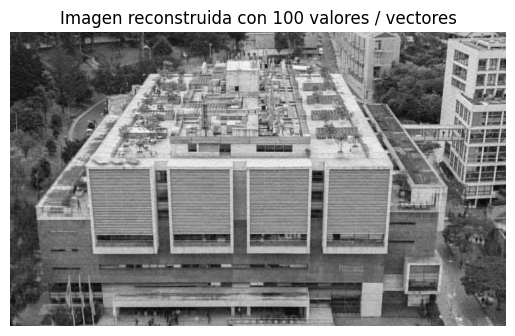

Tamaño de la imagen comprimida con parámetro p = 100: 127900 píxeles
Porcentaje de compresión: 60.629%


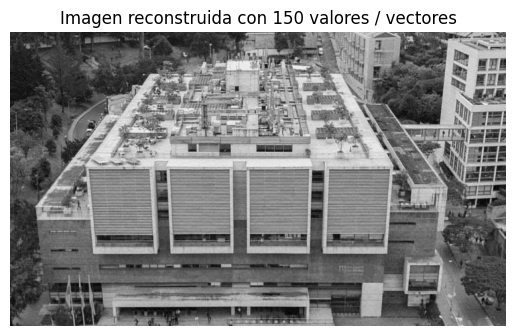

Tamaño de la imagen comprimida con parámetro p = 150: 199350 píxeles
Porcentaje de compresión: 38.635%


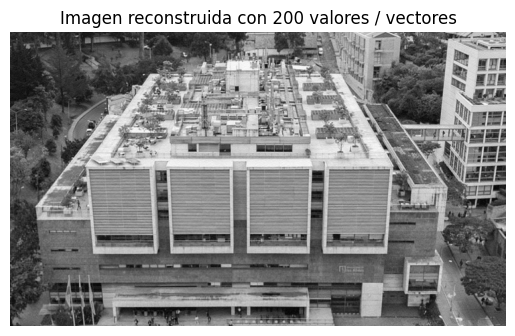

Tamaño de la imagen comprimida con parámetro p = 200: 275800 píxeles
Porcentaje de compresión: 15.102%


In [ ]:
# Se prueba con diferentes valores de p
p_valores = [20, 50, 75, 90, 100, 150, 200]
for p in p_valores:
    imagen_reconstruida = reconstruir_imagen(p)
    compressed_size = (U[:, :p].size + Sigma[:p, :p].size + Vt[:p, :].size)
    ratio = com_ratio(original_size, compressed_size)
    plt.imshow(imagen_reconstruida, cmap='gray')
    plt.title(f'Imagen reconstruida con {p} valores / vectores')
    plt.axis('off')
    plt.show()
    print(f'Tamaño de la imagen comprimida con parámetro p = {p}: {compressed_size} píxeles')
    print(f'Porcentaje de compresión: {ratio:.3f}%')


## **Conclusiones:**

- Considero que, para fines de inspección visual, un valor de p=90 es apropiado para esta imagen. Permite preservar un nivel de detalle aceptable en la estructura del edificio, que es el elemento central y el objetivo principal de la fotografía.
- Con p=90, el tamaño de la imagen comprimida es de aproximadamente 114,200 píxeles, lo que representa un 35 % del tamaño original, es decir, un ahorro del 65 % en almacenamiento.
- Aumentar el valor de p a partir de 90, representaría únicamente un aumento en el tamaño de la imagen final sin una significativa mejora en la calidad de la misma.
- Este proceso de descomposición en valores singulares (SVD) es una herramienta poderosa en el procesamiento de imágenes. Permite comprimir o manipular imágenes de forma eficiente mediante una técnica relativamente sencilla, lo cual refuerza la importancia del conocimiento de álgebra lineal para su correcta aplicación y comprensión.
